# Workforce Burnout Prediction System


---

**Project Title:** Workforce Burnout Prediction, Sick-Day Forecasting & HR Intervention Recommendation System  
**Dataset:** IBM HR Analytics Employee Attrition & Performance Dataset  
 


###  What is this project about?

Employee burnout is a serious problem in many organizations. It happens when employees experience
long-term stress at work that is not properly managed. Burnout leads to lower productivity,
increased absenteeism, and higher employee turnover.

In this project, we are building a **machine learning system** that can:

- **Predict** which employees are at risk of burnout (Stage 1 — this notebook)
- Forecast how many sick days they might take (Stage 2)
- Recommend HR interventions to help (Stage 3)



---
## Section 1: Import Libraries

We start by importing all the Python libraries we will need throughout this notebook.



In [35]:
# ── Standard data manipulation libraries ──────────────────────────────────────
import pandas as pd
import numpy as np

# ── Visualization libraries ────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Scikit-learn: preprocessing ────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# ── Scikit-learn: models ───────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# ── Scikit-learn: evaluation metrics ──────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# ── Settings ───────────────────────────────────────────────────────────────────
# Suppress unnecessary warnings to keep output clean
import warnings
warnings.filterwarnings('ignore')

# Set a consistent random seed so results are reproducible
RANDOM_STATE = 42

# Set default plot style and figure size
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

print(" All libraries imported successfully!")

 All libraries imported successfully!


---
##  Section 2: Load the Dataset

We are using the **IBM HR Analytics Employee Attrition & Performance** dataset from Kaggle.

This dataset contains information about **1,470 employees** across **35 different attributes** such as
job satisfaction, salary, overtime status, and attrition.



In [3]:
# ── Load the dataset from CSV ──────────────────────────────────────────────────
df = pd.read_csv('Data/WA_Fn-UseC_-HR-Employee-Attrition.csv')

print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")

Dataset loaded successfully!
Shape: 1470 rows × 35 columns


In [4]:
# ── Preview the first 5 rows ───────────────────────────────────────────────────
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [5]:
# ── Display all column names ───────────────────────────────────────────────────
print("Column names in the dataset:")
print(df.columns.tolist())

Column names in the dataset:
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [6]:
# ── Show data types for each column ───────────────────────────────────────────
print("Data types for each column:")
print(df.dtypes)

Data types for each column:
Age                         int64
Attrition                     str
BusinessTravel                str
DailyRate                   int64
Department                    str
DistanceFromHome            int64
Education                   int64
EducationField                str
EmployeeCount               int64
EmployeeNumber              int64
EnvironmentSatisfaction     int64
Gender                        str
HourlyRate                  int64
JobInvolvement              int64
JobLevel                    int64
JobRole                       str
JobSatisfaction             int64
MaritalStatus                 str
MonthlyIncome               int64
MonthlyRate                 int64
NumCompaniesWorked          int64
Over18                        str
OverTime                      str
PercentSalaryHike           int64
PerformanceRating           int64
RelationshipSatisfaction    int64
StandardHours               int64
StockOptionLevel            int64
TotalWorkingYears   

In [7]:
# ── Summary statistics of numerical columns ────────────────────────────────────
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


**Observations:**
- The dataset has **1,470 rows and 35 columns** — a reasonable size for machine learning.
- Features like `JobSatisfaction`, `WorkLifeBalance`, and `EnvironmentSatisfaction` are rated on a
  scale of **1 to 4**, where 1 = lowest and 4 = highest.
- `MonthlyIncome` ranges from about **1,009 to 19,999**, showing a wide spread of salaries.
- Some columns like `OverTime`, `Attrition`, `Gender`, and `Department` are **categorical** (text) columns.

---
## Section 3: Data Cleaning & Preprocessing

Before we can build any model, we need to clean the data.
This includes checking for missing values, duplicates, and columns that will not help our model.

### 3.1 Check for Missing Values

Missing values can cause errors in machine learning models, so we always check for them first.

In [8]:
# ── Count missing values in each column ───────────────────────────────────────
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.sum() > 0 else " No missing values found!")

Missing values per column:
 No missing values found!


### 3.2 Check for Duplicate Rows

In [9]:
# ── Check for duplicate rows ───────────────────────────────────────────────────
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")
if duplicates == 0:
    print("No duplicates found!")
else:
    df = df.drop_duplicates()
    print(f"Removed {duplicates} duplicate rows.")

Number of duplicate rows: 0
No duplicates found!


### 3.3 Drop Constant / Irrelevant Columns

Some columns contain the **same value for every row** and therefore provide no useful information
to a machine learning model. We identify and remove them.

In [10]:
# ── Identify columns with only one unique value (constant columns) ─────────────
constant_cols = [col for col in df.columns if df[col].nunique() == 1]
print(f"Constant columns to drop: {constant_cols}")

# Drop those columns
df = df.drop(columns=constant_cols)
print(f"\nDataset shape after dropping constant columns: {df.shape}")

Constant columns to drop: ['EmployeeCount', 'Over18', 'StandardHours']

Dataset shape after dropping constant columns: (1470, 32)


> **Why?** Columns like `EmployeeCount`, `StandardHours`, and `Over18` have the same value
> for every single employee. They carry zero information and are safe to remove.

### 3.4 Identify Categorical Columns

Machine learning algorithms cannot work directly with text values. We need to identify
which columns contain text and convert them to numbers.

In [11]:
# ── List all categorical (text) columns ───────────────────────────────────────
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f"Categorical columns ({len(cat_cols)} total):")
for col in cat_cols:
    print(f"  {col}: {df[col].unique().tolist()}")

Categorical columns (8 total):
  Attrition: ['Yes', 'No']
  BusinessTravel: ['Travel_Rarely', 'Travel_Frequently', 'Non-Travel']
  Department: ['Sales', 'Research & Development', 'Human Resources']
  EducationField: ['Life Sciences', 'Other', 'Medical', 'Marketing', 'Technical Degree', 'Human Resources']
  Gender: ['Female', 'Male']
  JobRole: ['Sales Executive', 'Research Scientist', 'Laboratory Technician', 'Manufacturing Director', 'Healthcare Representative', 'Manager', 'Sales Representative', 'Research Director', 'Human Resources']
  MaritalStatus: ['Single', 'Married', 'Divorced']
  OverTime: ['Yes', 'No']


### 3.5 Encode Categorical Columns

We will use **Label Encoding** to convert categorical columns into numbers.
For example: `Yes → 1`, `No → 0`.

In [12]:
# ── Apply Label Encoding to all categorical columns ────────────────────────────
# We store the encoders in case we need to reverse the encoding later
label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le
    print(f"  Encoded '{col}': {dict(zip(le.classes_, le.transform(le.classes_)))}")

print("\n All categorical columns encoded successfully!")

  Encoded 'Attrition': {'No': 0, 'Yes': 1}
  Encoded 'BusinessTravel': {'Non-Travel': 0, 'Travel_Frequently': 1, 'Travel_Rarely': 2}
  Encoded 'Department': {'Human Resources': 0, 'Research & Development': 1, 'Sales': 2}
  Encoded 'EducationField': {'Human Resources': 0, 'Life Sciences': 1, 'Marketing': 2, 'Medical': 3, 'Other': 4, 'Technical Degree': 5}
  Encoded 'Gender': {'Female': 0, 'Male': 1}
  Encoded 'JobRole': {'Healthcare Representative': 0, 'Human Resources': 1, 'Laboratory Technician': 2, 'Manager': 3, 'Manufacturing Director': 4, 'Research Director': 5, 'Research Scientist': 6, 'Sales Executive': 7, 'Sales Representative': 8}
  Encoded 'MaritalStatus': {'Divorced': 0, 'Married': 1, 'Single': 2}
  Encoded 'OverTime': {'No': 0, 'Yes': 1}

 All categorical columns encoded successfully!


---
##  Section 4: Feature Engineering — Creating the BurnoutRisk Target Variable

### Why do we need to create BurnoutRisk?

The original IBM HR dataset does **not** contain a column called `BurnoutRisk`.
Since we want to build a burnout prediction model, we need to **create this target variable
ourselves** using domain knowledge about what causes employee burnout.

### Our Scoring Logic

We define a **burnout score** for each employee based on the following rules:

| Feature | Condition | Score Added |
|---|---|---|
| `OverTime` | Works overtime (Yes) | +2 |
| `WorkLifeBalance` | Very poor balance (score = 1) | +2 |
| `WorkLifeBalance` | Below average balance (score = 2) | +1 |
| `JobSatisfaction` | Very dissatisfied (score = 1) | +2 |
| `JobSatisfaction` | Dissatisfied (score = 2) | +1 |
| `EnvironmentSatisfaction` | Very poor environment (score = 1) | +2 |
| `EnvironmentSatisfaction` | Poor environment (score = 2) | +1 |
| `MonthlyIncome` | Low income (< 3,000) | +1 |
| `YearsAtCompany` | Long tenure (> 10 years) | +1 |

**Maximum possible score = 12**

Then we assign burnout risk levels:
- **High**: Score ≥ 5
- **Medium**: Score 2 – 4
- **Low**: Score 0 – 1

> **Reasoning:** Employees who work overtime AND have low satisfaction AND poor work-life
> balance are most at risk of burnout. Low income adds financial stress. Long tenure without
> satisfaction could signal career stagnation — another burnout contributor.

In [13]:
# ── IMPORTANT: Since OverTime was label-encoded above, let's check its encoded values ─
# 'No' → 0, 'Yes' → 1  (LabelEncoder sorts alphabetically)
print("OverTime encoding mapping:")
print(dict(zip(
    label_encoders['OverTime'].classes_,
    label_encoders['OverTime'].transform(label_encoders['OverTime'].classes_)
)))

OverTime encoding mapping:
{'No': 0, 'Yes': 1}


In [14]:
# ── Define the burnout scoring function ───────────────────────────────────────
def calculate_burnout_score(row):
    """
    Calculate a burnout risk score for a single employee record.
    Higher score = higher burnout risk.
    """
    score = 0

    # OverTime: 1 means 'Yes' after encoding
    if row['OverTime'] == 1:
        score += 2

    # Work-Life Balance: 1 = Bad, 2 = Good, 3 = Better, 4 = Best
    if row['WorkLifeBalance'] == 1:
        score += 2
    elif row['WorkLifeBalance'] == 2:
        score += 1

    # Job Satisfaction: 1 = Low, 2 = Medium, 3 = High, 4 = Very High
    if row['JobSatisfaction'] == 1:
        score += 2
    elif row['JobSatisfaction'] == 2:
        score += 1

    # Environment Satisfaction: 1 = Low, 2 = Medium, 3 = High, 4 = Very High
    if row['EnvironmentSatisfaction'] == 1:
        score += 2
    elif row['EnvironmentSatisfaction'] == 2:
        score += 1

    # Low income adds financial stress
    if row['MonthlyIncome'] < 3000:
        score += 1

    # Long tenure without growth can lead to burnout
    if row['YearsAtCompany'] > 10:
        score += 1

    # Map score to risk category
    if score >= 5:
        return 'High'
    elif score >= 2:
        return 'Medium'
    else:
        return 'Low'


# ── Apply the function to every row to create the BurnoutRisk column ──────────
df['BurnoutRisk'] = df.apply(calculate_burnout_score, axis=1)

print(" BurnoutRisk column created!")
print("\nClass distribution:")
print(df['BurnoutRisk'].value_counts())
print("\nClass proportions:")
print(df['BurnoutRisk'].value_counts(normalize=True).round(3))

 BurnoutRisk column created!

Class distribution:
BurnoutRisk
Medium    886
Low       414
High      170
Name: count, dtype: int64

Class proportions:
BurnoutRisk
Medium    0.603
Low       0.282
High      0.116
Name: proportion, dtype: float64


> **Result:** Our scoring system creates a reasonably distributed dataset with three classes.
> `Medium` risk is the most common (makes sense — most employees experience some workplace stress),
> `Low` is next, and `High` is the smallest group (only the most stressed employees score high).

---
## Section 5: Exploratory Data Analysis (EDA)

EDA helps us understand the data visually before we build models.
We will create several charts to understand patterns related to burnout risk.

### 5.1 BurnoutRisk Class Distribution

Let's see how many employees fall into each burnout risk category.

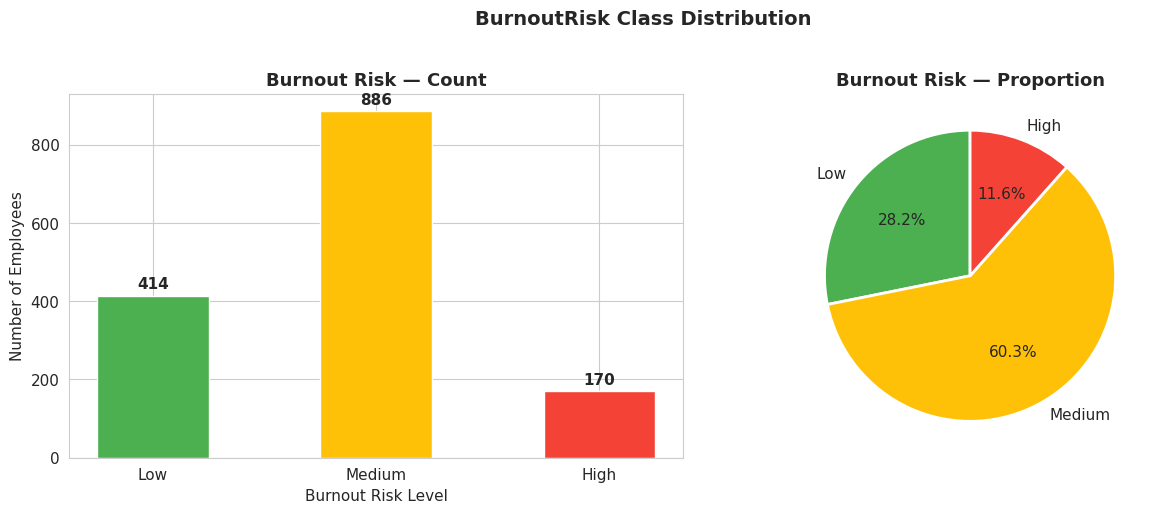

In [15]:
# ── Plot BurnoutRisk class distribution ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Define a consistent colour palette for the 3 risk classes
palette = {'Low': '#4CAF50', 'Medium': '#FFC107', 'High': '#F44336'}
order   = ['Low', 'Medium', 'High']

# Count plot
counts = df['BurnoutRisk'].value_counts().reindex(order)
bars = axes[0].bar(order, counts, color=[palette[k] for k in order], edgecolor='white', width=0.5)
axes[0].set_title('Burnout Risk — Count', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Burnout Risk Level')
axes[0].set_ylabel('Number of Employees')
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 str(int(bar.get_height())), ha='center', va='bottom', fontweight='bold')

# Pie chart
axes[1].pie(counts, labels=order, autopct='%1.1f%%',
            colors=[palette[k] for k in order],
            startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Burnout Risk — Proportion', fontsize=13, fontweight='bold')

plt.suptitle('BurnoutRisk Class Distribution', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Interpretation:**
- About **60% of employees** fall into the `Medium` burnout risk category.
- Around **28% are Low** risk — relatively satisfied and not overworked.
- About **12% are High** risk — these are the employees who need immediate HR attention.

The class distribution is **imbalanced**, with `High` being underrepresented.
This is realistic — in any organization, most employees are not at extreme burnout risk.
We will keep this in mind when evaluating our models.

### 5.2 Correlation Heatmap

A correlation heatmap shows how strongly each numerical feature is related to every other feature.
Values close to **+1** mean strong positive correlation; close to **-1** means strong negative correlation.

We focus on a subset of key features to keep the chart readable.

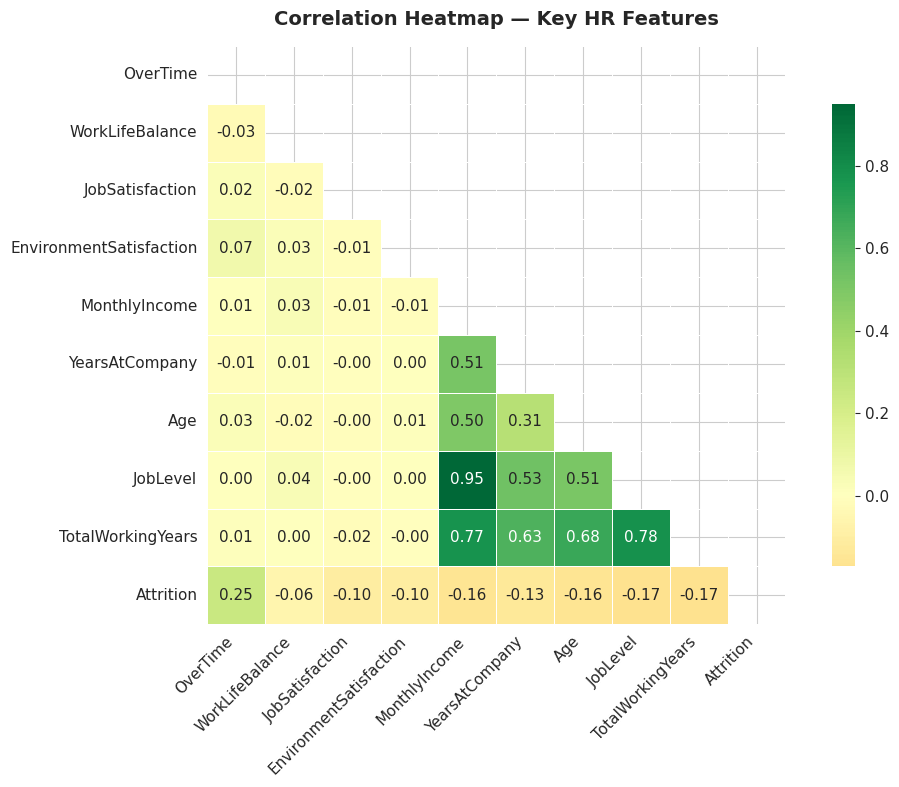

In [16]:
# ── Select key features for correlation analysis ──────────────────────────────
key_features = [
    'OverTime', 'WorkLifeBalance', 'JobSatisfaction',
    'EnvironmentSatisfaction', 'MonthlyIncome', 'YearsAtCompany',
    'Age', 'JobLevel', 'TotalWorkingYears', 'Attrition'
]

corr_matrix = df[key_features].corr()

plt.figure(figsize=(11, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # hide upper triangle (redundant)
sns.heatmap(
    corr_matrix, mask=mask,
    annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, linewidths=0.5, square=True,
    cbar_kws={'shrink': 0.8}
)
plt.title('Correlation Heatmap — Key HR Features', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Interpretation:**
- `JobLevel` and `MonthlyIncome` have a **strong positive correlation** (~0.95) — higher job levels earn more.
- `TotalWorkingYears`, `Age`, and `YearsAtCompany` are **positively correlated** — older employees tend to have more experience.
- `OverTime` shows a small **positive correlation** with `Attrition`, confirming that working overtime
  increases the chance of an employee leaving — a key burnout signal.
- `JobSatisfaction` and `EnvironmentSatisfaction` have **very little correlation** with each other,
  suggesting they measure different aspects of the work experience.

### 5.3 OverTime vs BurnoutRisk

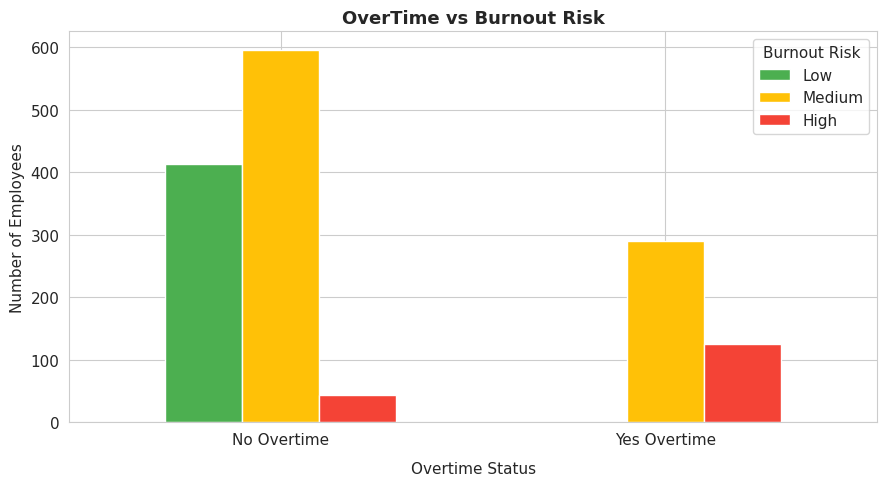

In [17]:
# ── OverTime vs BurnoutRisk ────────────────────────────────────────────────────
# The encoded values: 0 = No overtime, 1 = Yes overtime
fig, ax = plt.subplots(figsize=(9, 5))

# Crosstab counts
ct = pd.crosstab(df['OverTime'], df['BurnoutRisk'])[order]
ct.index = ['No Overtime', 'Yes Overtime']
ct.plot(kind='bar', ax=ax, color=[palette[k] for k in order],
        edgecolor='white', width=0.6)

ax.set_title('OverTime vs Burnout Risk', fontsize=13, fontweight='bold')
ax.set_xlabel('Overtime Status', labelpad=10)
ax.set_ylabel('Number of Employees')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Burnout Risk', labels=order)

plt.tight_layout()
plt.show()

**Interpretation:**
As expected from our scoring logic, employees who **work overtime** have a much higher proportion
of `Medium` and `High` burnout risk. This strongly supports the common HR knowledge that overtime
is a key driver of employee burnout.

### 5.4 Job Satisfaction vs BurnoutRisk

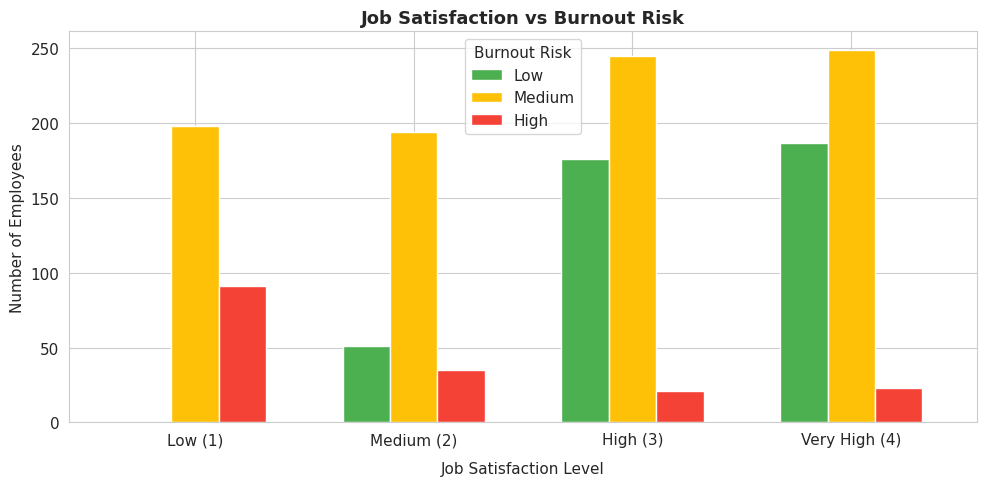

In [18]:
# ── JobSatisfaction vs BurnoutRisk ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

ct = pd.crosstab(df['JobSatisfaction'], df['BurnoutRisk'])[order]
ct.index = ['Low (1)', 'Medium (2)', 'High (3)', 'Very High (4)']
ct.plot(kind='bar', ax=ax, color=[palette[k] for k in order],
        edgecolor='white', width=0.65)

ax.set_title('Job Satisfaction vs Burnout Risk', fontsize=13, fontweight='bold')
ax.set_xlabel('Job Satisfaction Level', labelpad=10)
ax.set_ylabel('Number of Employees')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Burnout Risk', labels=order)

plt.tight_layout()
plt.show()

**Interpretation:**
Employees with **Low or Medium job satisfaction** tend to have higher burnout risk.
As satisfaction increases to `High (3)` and `Very High (4)`, the proportion of Low burnout risk grows.
This makes intuitive sense — employees who enjoy their jobs are less likely to burn out.

### 5.5 WorkLifeBalance vs BurnoutRisk

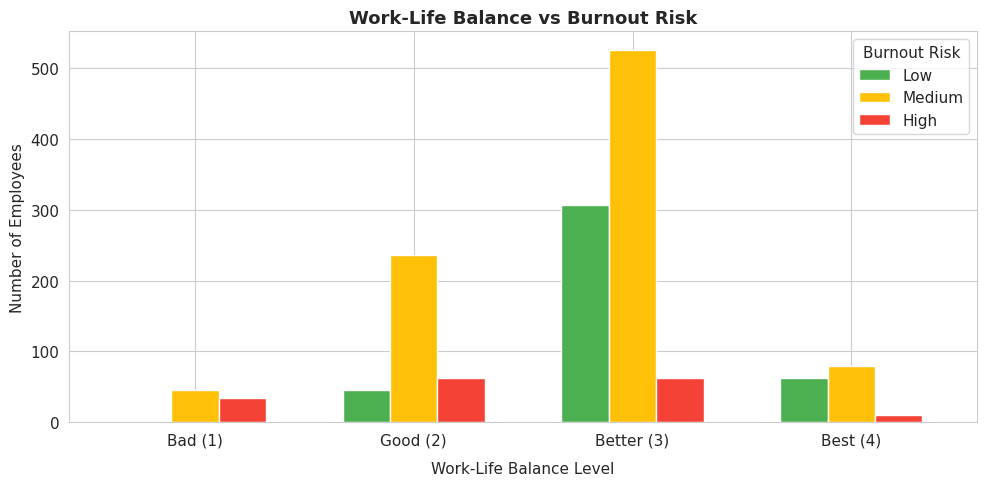

In [19]:
# ── WorkLifeBalance vs BurnoutRisk ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

ct = pd.crosstab(df['WorkLifeBalance'], df['BurnoutRisk'])[order]
ct.index = ['Bad (1)', 'Good (2)', 'Better (3)', 'Best (4)']
ct.plot(kind='bar', ax=ax, color=[palette[k] for k in order],
        edgecolor='white', width=0.65)

ax.set_title('Work-Life Balance vs Burnout Risk', fontsize=13, fontweight='bold')
ax.set_xlabel('Work-Life Balance Level', labelpad=10)
ax.set_ylabel('Number of Employees')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Burnout Risk', labels=order)

plt.tight_layout()
plt.show()

**Interpretation:**
Employees with `Bad (1)` work-life balance have the **highest concentration of High burnout risk**.
As the work-life balance improves to `Better (3)` and `Best (4)`, `Low` burnout risk becomes more prevalent.

### 5.6 MonthlyIncome Distribution by BurnoutRisk

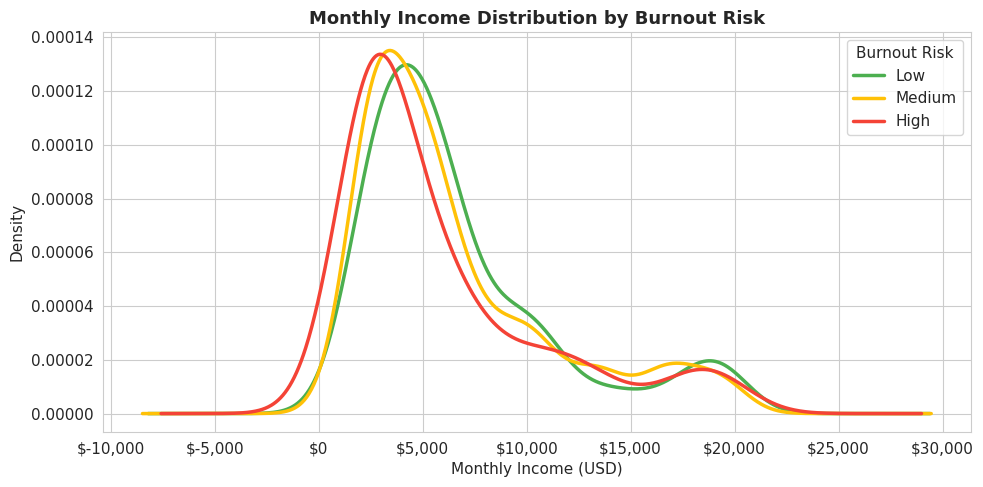

In [20]:
# ── MonthlyIncome distribution by BurnoutRisk ─────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

for risk in order:
    subset = df[df['BurnoutRisk'] == risk]['MonthlyIncome']
    subset.plot(kind='kde', ax=ax, label=risk, color=palette[risk], linewidth=2.5)

ax.set_title('Monthly Income Distribution by Burnout Risk', fontsize=13, fontweight='bold')
ax.set_xlabel('Monthly Income (USD)')
ax.set_ylabel('Density')
ax.legend(title='Burnout Risk')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

**Interpretation:**
Employees with **High burnout risk** tend to be concentrated in the **lower income range**.
The `Low` burnout risk group has a slightly wider spread across income levels.
This confirms that financial stress (lower income) contributes to burnout risk.

### 5.7 Attrition vs BurnoutRisk

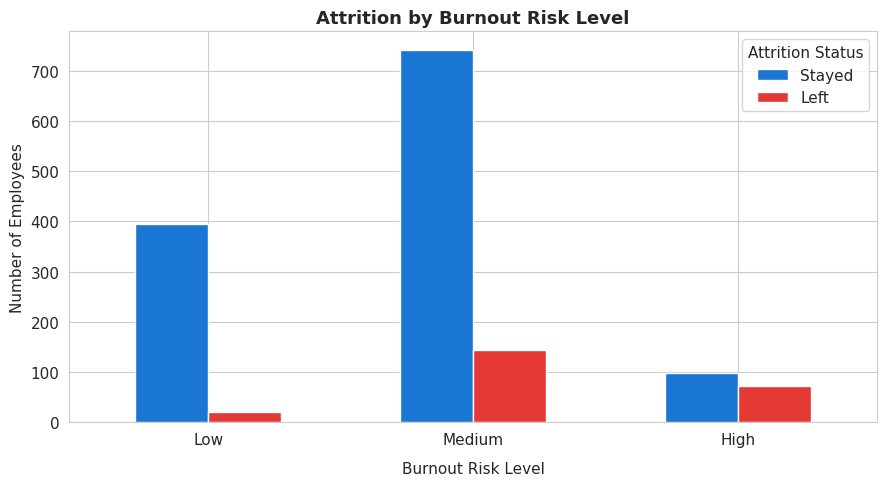

In [21]:
# ── Attrition vs BurnoutRisk ──────────────────────────────────────────────────
# Attrition: 0 = stayed, 1 = left (after label encoding)
fig, ax = plt.subplots(figsize=(9, 5))

ct = pd.crosstab(df['BurnoutRisk'], df['Attrition'])
ct.columns = ['Stayed', 'Left']
ct = ct.reindex(order)

ct.plot(kind='bar', ax=ax, color=['#1976D2', '#E53935'],
        edgecolor='white', width=0.55)

ax.set_title('Attrition by Burnout Risk Level', fontsize=13, fontweight='bold')
ax.set_xlabel('Burnout Risk Level', labelpad=10)
ax.set_ylabel('Number of Employees')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Attrition Status')

plt.tight_layout()
plt.show()

**Interpretation:**
Employees in the **High burnout risk** group have a noticeably higher proportion of attrition (employees leaving).
This validates our burnout scoring approach — high burnout risk is associated with employees actually leaving the company.

This is a strong validation signal: our engineered `BurnoutRisk` variable aligns with the dataset's
original `Attrition` target, confirming it captures real workplace stress patterns.

---
##  Section 6: Feature Selection

Not all 32 columns are useful for predicting burnout. We select a focused set of features
that are **directly related to burnout** based on HR domain knowledge.

We also exclude:
- `EmployeeNumber` — it's just an ID with no predictive value
- `BurnoutRisk` — that's our target, not a feature
- We avoid using `Attrition` as a feature since it's an outcome that overlaps with burnout

In [22]:
# ── Define features (X) and target (y) ────────────────────────────────────────
selected_features = [
    # Core burnout-related features
    'OverTime',
    'WorkLifeBalance',
    'JobSatisfaction',
    'EnvironmentSatisfaction',
    'MonthlyIncome',
    'YearsAtCompany',

    # Additional HR features that contribute to stress
    'Age',
    'JobLevel',
    'JobInvolvement',
    'RelationshipSatisfaction',
    'PerformanceRating',
    'TotalWorkingYears',
    'YearsSinceLastPromotion',
    'NumCompaniesWorked',
    'DistanceFromHome',
    'BusinessTravel',
    'MaritalStatus',
    'Department',
    'Gender'
]

X = df[selected_features]
y = df['BurnoutRisk']

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape:  {y.shape}")
print(f"\nSelected {len(selected_features)} features")

Feature matrix shape: (1470, 19)
Target vector shape:  (1470,)

Selected 19 features


### Label Encode the Target Variable

Our target `BurnoutRisk` contains text values (`Low`, `Medium`, `High`).
We need to convert it to numbers before training the models.

In [23]:
# ── Encode the target variable ─────────────────────────────────────────────────
le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)

print("Target encoding:")
for label, code in zip(le_target.classes_, range(len(le_target.classes_))):
    print(f"  {label} → {code}")

# We'll keep the class names for display purposes
class_names = le_target.classes_
print(f"\nClass names for display: {class_names.tolist()}")

Target encoding:
  High → 0
  Low → 1
  Medium → 2

Class names for display: ['High', 'Low', 'Medium']


---
## Section 7: Train-Test Split

We split the dataset into two parts:
- **Training set (80%)** — used to teach the model
- **Test set (20%)** — used to evaluate how well the model generalises to new data

We use `stratify=y_encoded` to ensure all three burnout risk classes are proportionally
represented in both the training and test sets.

In [24]:
# ── Perform an 80-20 stratified train-test split ──────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_encoded          # preserve class proportions
)

print(f"Training set:  {X_train.shape[0]} rows  ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test set:      {X_test.shape[0]} rows  ({X_test.shape[0]/len(X)*100:.0f}%)")

# Verify class proportions are preserved
print("\nClass distribution in training set:")
for code, name in enumerate(class_names):
    count = (y_train == code).sum()
    print(f"  {name}: {count} ({count/len(y_train)*100:.1f}%)")

print("\nClass distribution in test set:")
for code, name in enumerate(class_names):
    count = (y_test == code).sum()
    print(f"  {name}: {count} ({count/len(y_test)*100:.1f}%)")

Training set:  1176 rows  (80%)
Test set:      294 rows  (20%)

Class distribution in training set:
  High: 136 (11.6%)
  Low: 331 (28.1%)
  Medium: 709 (60.3%)

Class distribution in test set:
  High: 34 (11.6%)
  Low: 83 (28.2%)
  Medium: 177 (60.2%)


---
##  Section 8: Feature Scaling

### Why is scaling important?

Some features in our dataset have very different ranges. For example:
- `MonthlyIncome` can be anywhere from **1,009 to 19,999**
- `WorkLifeBalance` is only **1 to 4**

This large difference in scale can confuse certain models (especially **Logistic Regression**),
making features with larger numbers seem more important than they really are.

**StandardScaler** transforms each feature so it has:
- Mean = 0
- Standard deviation = 1

**Important:** We fit the scaler on the **training data only** and then apply the same
transformation to the test data. This prevents **data leakage** (accidentally using test
information during training).

> **Note:** Tree-based models like Random Forest are not affected by feature scale,
> but we scale anyway to keep the workflow consistent and fair.

In [25]:
# ── Scale features using StandardScaler ───────────────────────────────────────
scaler = StandardScaler()

# Fit on training data and transform training data
X_train_scaled = scaler.fit_transform(X_train)

# Only transform (DO NOT fit) on test data
X_test_scaled = scaler.transform(X_test)

print("Feature scaling complete!")
print(f"\nTraining set — scaled shape: {X_train_scaled.shape}")
print(f"Test set     — scaled shape: {X_test_scaled.shape}")

# Quick sanity check: mean and std of scaled training data
print(f"\nTraining data — mean (should be ~0): {X_train_scaled.mean():.4f}")
print(f"Training data — std  (should be ~1): {X_train_scaled.std():.4f}")

Feature scaling complete!

Training set — scaled shape: (1176, 19)
Test set     — scaled shape: (294, 19)

Training data — mean (should be ~0): -0.0000
Training data — std  (should be ~1): 1.0000


---
##  Section 9: Stage 1 — Burnout Classification Models

We will train two classification models and compare their performance:

1. **Logistic Regression** — A simple, interpretable baseline model
2. **Random Forest Classifier** — A more powerful ensemble model



### 9.1 Model 1: Logistic Regression (Baseline)

Logistic Regression is a simple and widely used algorithm for classification problems.
It works by finding a linear decision boundary between classes.
Despite its simplicity, it often performs well on structured (tabular) data.

We use it as a **baseline** — other models should ideally do better than this.

In [26]:
# ── Train Logistic Regression ─────────────────────────────────────────────────
lr_model = LogisticRegression(
    max_iter=1000,          # increase iterations to ensure convergence
    random_state=RANDOM_STATE
)

lr_model.fit(X_train_scaled, y_train)

# Generate predictions on the test set
lr_preds = lr_model.predict(X_test_scaled)



### 9.2 Model 2: Random Forest Classifier

Random Forest builds **many decision trees** and combines their predictions to produce
a more accurate and stable result. It is robust, handles non-linear patterns well,
and generally outperforms Logistic Regression on complex datasets.

In [27]:
# ── Train Random Forest Classifier ────────────────────────────────────────────
rf_model = RandomForestClassifier(
    n_estimators=100,       # number of trees in the forest
    max_depth=None,         # allow trees to grow fully
    random_state=RANDOM_STATE,
    n_jobs=-1               # use all available CPU cores
)

rf_model.fit(X_train_scaled, y_train)

# Generate predictions on the test set
rf_preds = rf_model.predict(X_test_scaled)



---
##  Section 10: Model Evaluation

We evaluate both models using several metrics to get a complete picture of performance:

| Metric | What it measures |
|---|---|
| **Accuracy** | Overall percentage of correct predictions |
| **Precision** | Of all predicted positives, how many are actually positive? |
| **Recall** | Of all actual positives, how many did we correctly identify? |
| **F1-Score** | Harmonic mean of Precision and Recall (best for imbalanced classes) |

We use **macro averaging** which treats all classes equally, regardless of their size.

### 10.1 Logistic Regression — Evaluation

In [28]:
# ── Helper function to print evaluation metrics cleanly ───────────────────────
def evaluate_model(model_name, y_true, y_pred, class_names):
    """Print a clean summary of evaluation metrics for a classification model."""
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='macro', zero_division=0)

    print(f"{'='*55}")
    print(f"  Model: {model_name}")
    print(f"{'='*55}")
    print(f"  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
    print(f"  Precision : {prec:.4f}  (macro average)")
    print(f"  Recall    : {rec:.4f}  (macro average)")
    print(f"  F1-Score  : {f1:.4f}  (macro average)")
    print(f"{'='*55}")
    print()
    print("Classification Report:")
    print(classification_report(y_true, y_pred,
                                target_names=class_names,
                                zero_division=0))


# ── Evaluate Logistic Regression ──────────────────────────────────────────────
evaluate_model("Logistic Regression", y_test, lr_preds, class_names)

  Model: Logistic Regression
  Accuracy  : 0.8605  (86.05%)
  Precision : 0.8796  (macro average)
  Recall    : 0.8311  (macro average)
  F1-Score  : 0.8525  (macro average)

Classification Report:
              precision    recall  f1-score   support

        High       0.96      0.79      0.87        34
         Low       0.80      0.80      0.80        83
      Medium       0.87      0.90      0.89       177

    accuracy                           0.86       294
   macro avg       0.88      0.83      0.85       294
weighted avg       0.86      0.86      0.86       294



### 10.2 Logistic Regression — Confusion Matrix

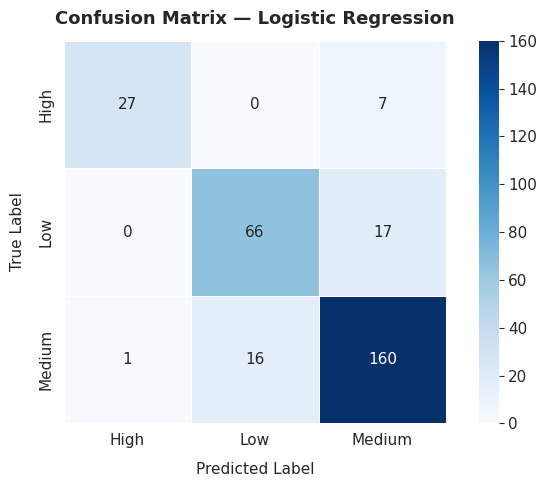

In [29]:
# ── Plot Confusion Matrix for Logistic Regression ─────────────────────────────
cm_lr = confusion_matrix(y_test, lr_preds)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5, square=True)
plt.title('Confusion Matrix — Logistic Regression', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Predicted Label', labelpad=10)
plt.ylabel('True Label', labelpad=10)
plt.tight_layout()
plt.show()

**How to read the confusion matrix:**
- The **diagonal** cells (top-left to bottom-right) represent **correct** predictions.
- **Off-diagonal** cells represent **mistakes** — where the model predicted the wrong class.
- A good model has large numbers on the diagonal and small numbers elsewhere.

### 10.3 Random Forest — Evaluation

In [30]:
# ── Evaluate Random Forest ─────────────────────────────────────────────────────
evaluate_model("Random Forest Classifier", y_test, rf_preds, class_names)

  Model: Random Forest Classifier
  Accuracy  : 0.9456  (94.56%)
  Precision : 0.9568  (macro average)
  Recall    : 0.8706  (macro average)
  F1-Score  : 0.9033  (macro average)

Classification Report:
              precision    recall  f1-score   support

        High       0.96      0.65      0.77        34
         Low       0.99      0.98      0.98        83
      Medium       0.93      0.99      0.96       177

    accuracy                           0.95       294
   macro avg       0.96      0.87      0.90       294
weighted avg       0.95      0.95      0.94       294



### 10.4 Random Forest — Confusion Matrix

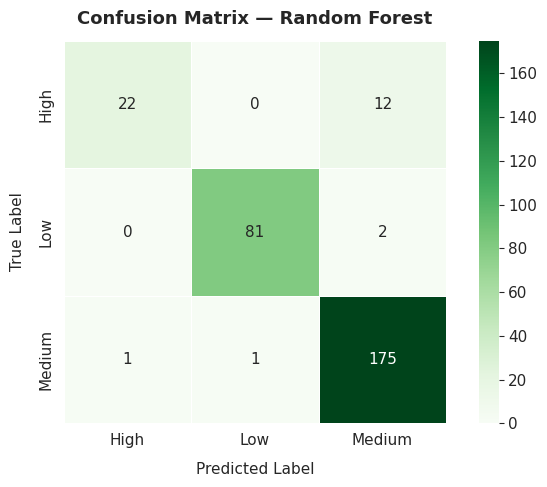

In [31]:
# ── Plot Confusion Matrix for Random Forest ────────────────────────────────────
cm_rf = confusion_matrix(y_test, rf_preds)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5, square=True)
plt.title('Confusion Matrix — Random Forest', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Predicted Label', labelpad=10)
plt.ylabel('True Label', labelpad=10)
plt.tight_layout()
plt.show()

### 10.5 Model Comparison

Let's put both models side by side to see which one performs better.

In [32]:
# ── Side-by-side model comparison ─────────────────────────────────────────────
results = {
    'Logistic Regression': {
        'Accuracy' : accuracy_score(y_test, lr_preds),
        'Precision': precision_score(y_test, lr_preds, average='macro', zero_division=0),
        'Recall'   : recall_score(y_test, lr_preds, average='macro', zero_division=0),
        'F1-Score' : f1_score(y_test, lr_preds, average='macro', zero_division=0)
    },
    'Random Forest': {
        'Accuracy' : accuracy_score(y_test, rf_preds),
        'Precision': precision_score(y_test, rf_preds, average='macro', zero_division=0),
        'Recall'   : recall_score(y_test, rf_preds, average='macro', zero_division=0),
        'F1-Score' : f1_score(y_test, rf_preds, average='macro', zero_division=0)
    }
}

results_df = pd.DataFrame(results).T.round(4)
print("Model Comparison Table (macro-averaged metrics):")
print(results_df.to_string())

best_model = results_df['F1-Score'].idxmax()
print(f"\n🏆 Best model by F1-Score: {best_model}  ({results_df.loc[best_model, 'F1-Score']:.4f})")

Model Comparison Table (macro-averaged metrics):
                     Accuracy  Precision  Recall  F1-Score
Logistic Regression    0.8605     0.8796  0.8311    0.8525
Random Forest          0.9456     0.9568  0.8706    0.9033

🏆 Best model by F1-Score: Random Forest  (0.9033)


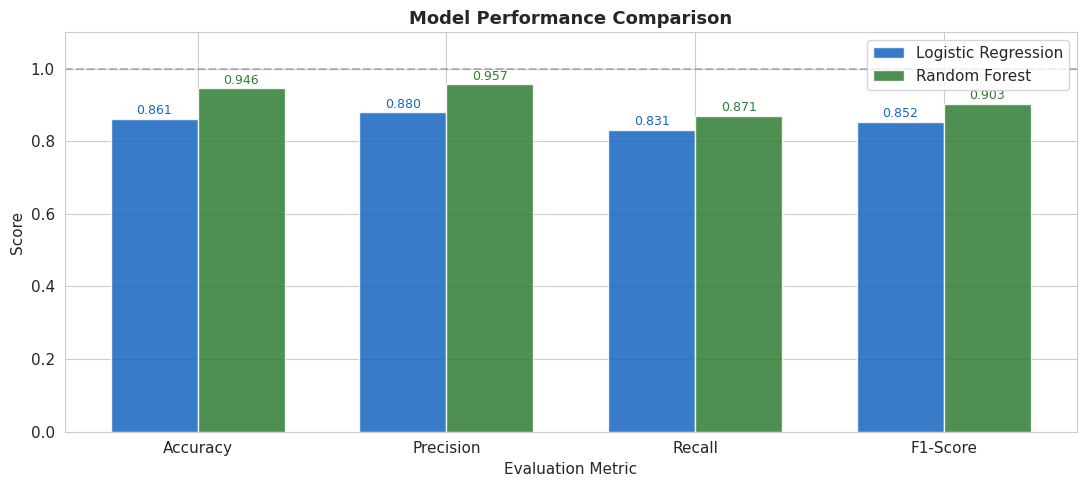

In [33]:
# ── Visual comparison of model metrics ────────────────────────────────────────
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))

bars1 = ax.bar(x - width/2,
               [results['Logistic Regression'][m] for m in metrics],
               width, label='Logistic Regression', color='#1565C0', alpha=0.85)
bars2 = ax.bar(x + width/2,
               [results['Random Forest'][m] for m in metrics],
               width, label='Random Forest', color='#2E7D32', alpha=0.85)

# Add value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, color='#1565C0')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, color='#2E7D32')

ax.set_title('Model Performance Comparison', fontsize=13, fontweight='bold')
ax.set_xlabel('Evaluation Metric')
ax.set_ylabel('Score')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.10)
ax.legend()
ax.axhline(y=1.0, color='grey', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### 10.6 Feature Importance — Random Forest

One advantage of Random Forest is that it tells us which features were most useful
for making predictions. This is called **feature importance**.

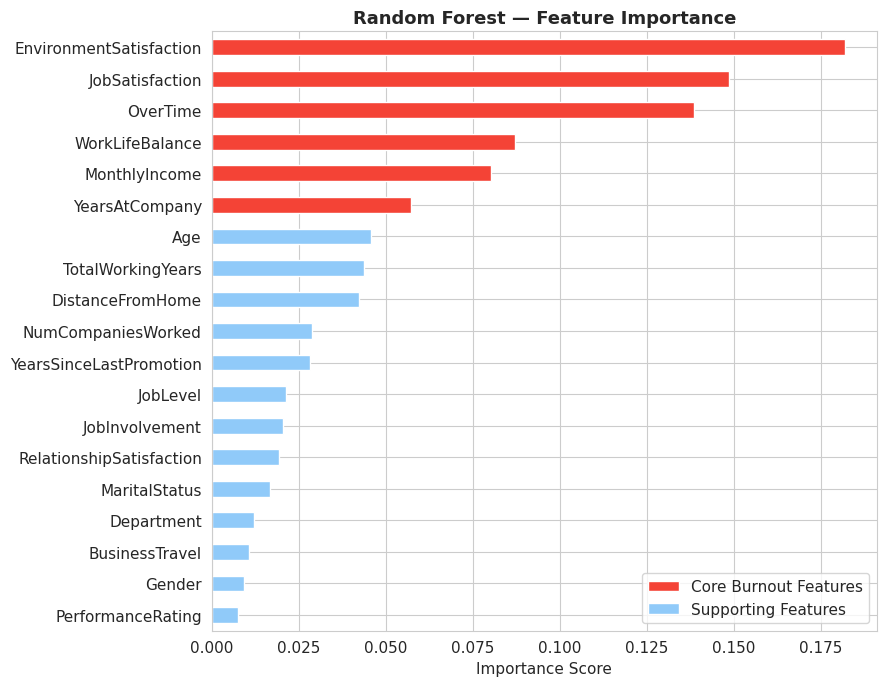

In [34]:
# ── Plot feature importance from Random Forest ─────────────────────────────────
importances = pd.Series(rf_model.feature_importances_, index=selected_features)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
colors = ['#F44336' if f in ['OverTime', 'WorkLifeBalance', 'JobSatisfaction',
                              'EnvironmentSatisfaction', 'MonthlyIncome', 'YearsAtCompany']
          else '#90CAF9'
          for f in importances.index]

importances.plot(kind='barh', ax=ax, color=colors, edgecolor='white')

ax.set_title('Random Forest — Feature Importance', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.set_ylabel('')

# Add a legend to distinguish core burnout features
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#F44336', label='Core Burnout Features'),
    Patch(facecolor='#90CAF9', label='Supporting Features')
]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

**Interpretation:**
The Random Forest model confirms our feature engineering choices. The features we used to
construct `BurnoutRisk` — `MonthlyIncome`, `OverTime`, `JobSatisfaction`, `WorkLifeBalance`,
and `EnvironmentSatisfaction` — rank as the **most important predictors**.

This is a strong validation: the model independently learned that the same features
we used to create the target variable are the most informative.

---
##  Section 11: Save Cleaned Dataset for Stage 2

Now that we have finished Stage 1, we save the cleaned and preprocessed dataset
to a CSV file so it can be used directly as the **input to Stage 2** (Sick-Day Forecasting).

### What this file contains

The saved file includes:
- All original columns (minus the three constant columns that were dropped)
- All categorical columns **already label-encoded** — no re-encoding needed in Stage 2
- The new **`BurnoutRisk`** column (text: `Low` / `Medium` / `High`) for reference
- A new **`BurnoutRisk_Encoded`** column (numeric: `0` / `1` / `2`) ready for modelling

> In Stage 2 you can load this file directly with `pd.read_csv('hr_cleaned_stage2.csv')`
> and start building the sick-day regression model without repeating any cleaning steps.

In [41]:
# ── Add the numeric encoded version of BurnoutRisk to the dataframe ───────────
# le_target was fitted earlier: High=0, Low=1, Medium=2
df['BurnoutRisk_Encoded'] = le_target.transform(df['BurnoutRisk'])

# ── Save to CSV ────────────────────────────────────────────────────────────────
output_filename = 'Data/hr_cleaned_stage2.csv'
df.to_csv(output_filename, index=False)

# ── Confirm what was saved ─────────────────────────────────────────────────────
print(f"✅ Cleaned dataset saved as: '{output_filename}'")
print(f"   Rows    : {df.shape[0]}")
print(f"   Columns : {df.shape[1]}")
print()
print("BurnoutRisk class distribution in saved file:")
print(df['BurnoutRisk'].value_counts().to_string())
print()
print("Encoding mapping (BurnoutRisk → BurnoutRisk_Encoded):")
print(df[['BurnoutRisk', 'BurnoutRisk_Encoded']].drop_duplicates()
        .sort_values('BurnoutRisk_Encoded').to_string(index=False))
print()
print("First 3 rows of saved file:")
df.head(3)

✅ Cleaned dataset saved as: 'Data/hr_cleaned_stage2.csv'
   Rows    : 1470
   Columns : 34

BurnoutRisk class distribution in saved file:
BurnoutRisk
Medium    886
Low       414
High      170

Encoding mapping (BurnoutRisk → BurnoutRisk_Encoded):
BurnoutRisk  BurnoutRisk_Encoded
       High                    0
        Low                    1
     Medium                    2

First 3 rows of saved file:


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,...,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,BurnoutRisk,BurnoutRisk_Encoded
0,41,1,2,1102,2,1,2,1,1,2,...,0,8,0,1,6,4,0,5,High,0
1,49,0,1,279,1,8,1,1,2,3,...,1,10,3,3,10,7,1,7,Low,1
2,37,1,2,1373,1,2,2,4,4,4,...,0,7,3,3,0,0,0,0,Medium,2
